In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1. Import the dataset using Pandas from above mentioned url.
print("--- 1. Importing the dataset ---")
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"
df = pd.read_csv(url)
print("Dataset imported successfully.\n")

--- 1. Importing the dataset ---
Dataset imported successfully.



In [3]:
# 2. High Level Data Understanding
print("--- 2. High Level Data Understanding ---")
# a. Find no. of rows & columns in the dataset
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

--- 2. High Level Data Understanding ---
Number of rows: 57394, Number of columns: 49


In [4]:

# b. Data types of columns
print("\nData types of columns:")
print(df.dtypes)


Data types of columns:
iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             float64
weekly_icu

In [6]:
# c. Info & describe of data in dataframe
print("\nData Info:")
test = df.info()
print("\nData Describe:")
print(df.describe())
print("\n")



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            57071 non-null  object 
 1   continent                           56748 non-null  object 
 2   location                            57394 non-null  object 
 3   date                                57394 non-null  object 
 4   total_cases                         53758 non-null  float64
 5   new_cases                           56465 non-null  float64
 6   new_cases_smoothed                  55652 non-null  float64
 7   total_deaths                        44368 non-null  float64
 8   new_deaths                          56465 non-null  float64
 9   new_deaths_smoothed                 55652 non-null  float64
 10  total_cases_per_million             53471 non-null  float64
 11  new_cases_per_million        

In [7]:
# 3. Low Level Data Understanding
print("--- 3. Low Level Data Understanding ---")
# a. Find count of unique values in location column.
print(f"Count of unique locations: {df['location'].nunique()}")


--- 3. Low Level Data Understanding ---
Count of unique locations: 216


In [8]:
# b. Find which continent has maximum frequency using values counts.
print(f"Continent with maximum frequency: {df['continent'].value_counts().idxmax()}")


Continent with maximum frequency: Europe


In [9]:
# c. Find maximum & mean value in 'total_cases'.
print(f"Maximum 'total_cases': {df['total_cases'].max()}")
print(f"Mean 'total_cases': {df['total_cases'].mean()}")



Maximum 'total_cases': 55154651.0
Mean 'total_cases': 167797.3688753302


In [10]:
# d. Find 25%, 50% & 75% quartile value in 'total_deaths'.
print(f"\nQuartiles for 'total_deaths':\n{df['total_deaths'].quantile([0.25, 0.5, 0.75])}")



Quartiles for 'total_deaths':
0.25     13.0
0.50     84.0
0.75    727.0
Name: total_deaths, dtype: float64


In [11]:

# e. Find which continent has maximum 'human_development_index'.
max_hdi_idx = df['human_development_index'].idxmax()
print(f"Continent with maximum 'human_development_index': {df.loc[max_hdi_idx, 'continent']}")


Continent with maximum 'human_development_index': Europe


In [12]:
# f. Find which continent has minimum 'gdp_per_capita'.
min_gdp_idx = df['gdp_per_capita'].idxmin()
print(f"Continent with minimum 'gdp_per_capita': {df.loc[min_gdp_idx, 'continent']}")
print("\n")


Continent with minimum 'gdp_per_capita': Africa




In [13]:
# 4. Filter the dataframe with only this columns
print("--- 4. Filtering the dataframe ---")
columns_to_keep = [
    'continent', 'location', 'date', 'total_cases', 
    'total_deaths', 'gdp_per_capita', 'human_development_index'
]
df = df[columns_to_keep]
print(f"Dataframe filtered. New shape: {df.shape}\n")


--- 4. Filtering the dataframe ---
Dataframe filtered. New shape: (57394, 7)



In [14]:
# 5. Data Cleaning
print("--- 5. Data Cleaning ---")
# a. Remove all duplicates observations
df = df.drop_duplicates()



--- 5. Data Cleaning ---


In [15]:
# b. Find missing values in all columns
print("Missing values in all columns before cleaning:")
print(df.isnull().sum())


Missing values in all columns before cleaning:
continent                    646
location                       0
date                           0
total_cases                 3636
total_deaths               13026
gdp_per_capita              7027
human_development_index     8147
dtype: int64


In [16]:
# c. Remove all observations where continent column value is missing
df = df.dropna(subset=['continent'])


In [27]:


# 6. Date time format
print("--- 6. Date time format ---")
# a. Convert date column in datetime format using pandas.to_datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')


--- 6. Date time format ---


In [28]:
# b. Create new column month after extracting month data from date column.
df['month'] = df['date'].dt.month
print("Date column converted and month column created.\n")



Date column converted and month column created.



In [29]:
# 7. Data Aggregation
print("--- 7. Data Aggregation ---")
# a. Find max value in all columns using groupby function on 'continent' column 
df_groupby = df.groupby('continent').max().reset_index()
print("Data aggregated into 'df_groupby' dataframe.\n")



--- 7. Data Aggregation ---
Data aggregated into 'df_groupby' dataframe.



In [30]:
# 8. Feature Engineering
print("--- 8. Feature Engineering ---")
# a. Create a new feature 'total_deaths_to_total_cases' by ratio of 'total_deaths' column to 'total_cases'
df_groupby['total_deaths_to_total_cases'] = df_groupby['total_deaths'] / df_groupby['total_cases']
print("Feature 'total_deaths_to_total_cases' created.\n")



--- 8. Feature Engineering ---
Feature 'total_deaths_to_total_cases' created.



In [31]:

# 9. Data Visualization
print("--- 9. Data Visualization ---")
print("Generating plots...")



--- 9. Data Visualization ---
Generating plots...


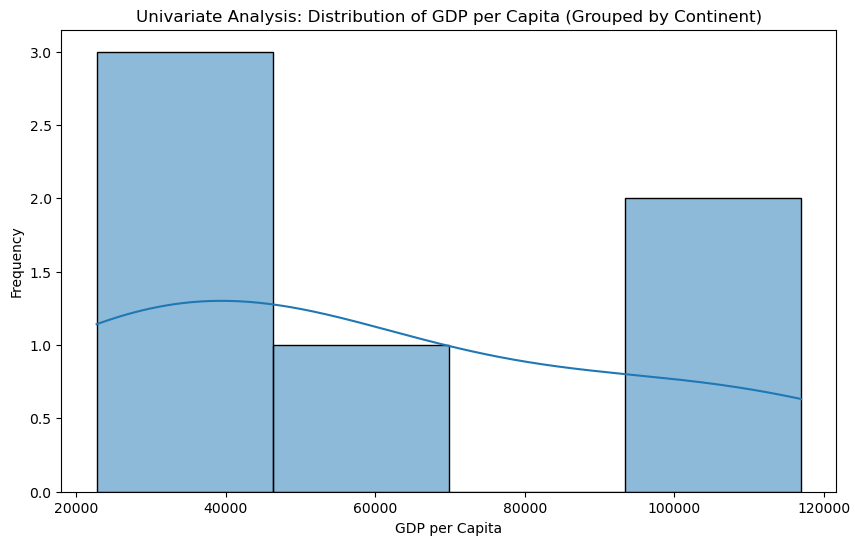

In [32]:

# a. Perform Univariate analysis on 'gdp_per_capita' column by plotting histogram using seaborn dist plot.
plt.figure(figsize=(10, 6))
# Using histplot instead of deprecated distplot while keeping the similar dist plot look
sns.histplot(df_groupby['gdp_per_capita'], kde=True)
plt.title('Univariate Analysis: Distribution of GDP per Capita (Grouped by Continent)')
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.show()



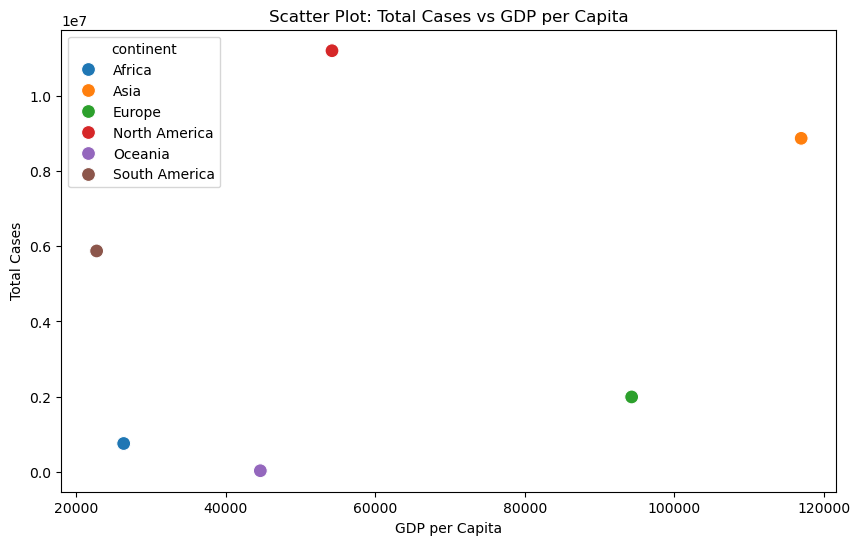

In [33]:

# b. Plot a scatter plot of 'total_cases' & 'gdp_per_capita'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_groupby, x='gdp_per_capita', y='total_cases', hue='continent', s=100)
plt.title('Scatter Plot: Total Cases vs GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Total Cases')
plt.show()



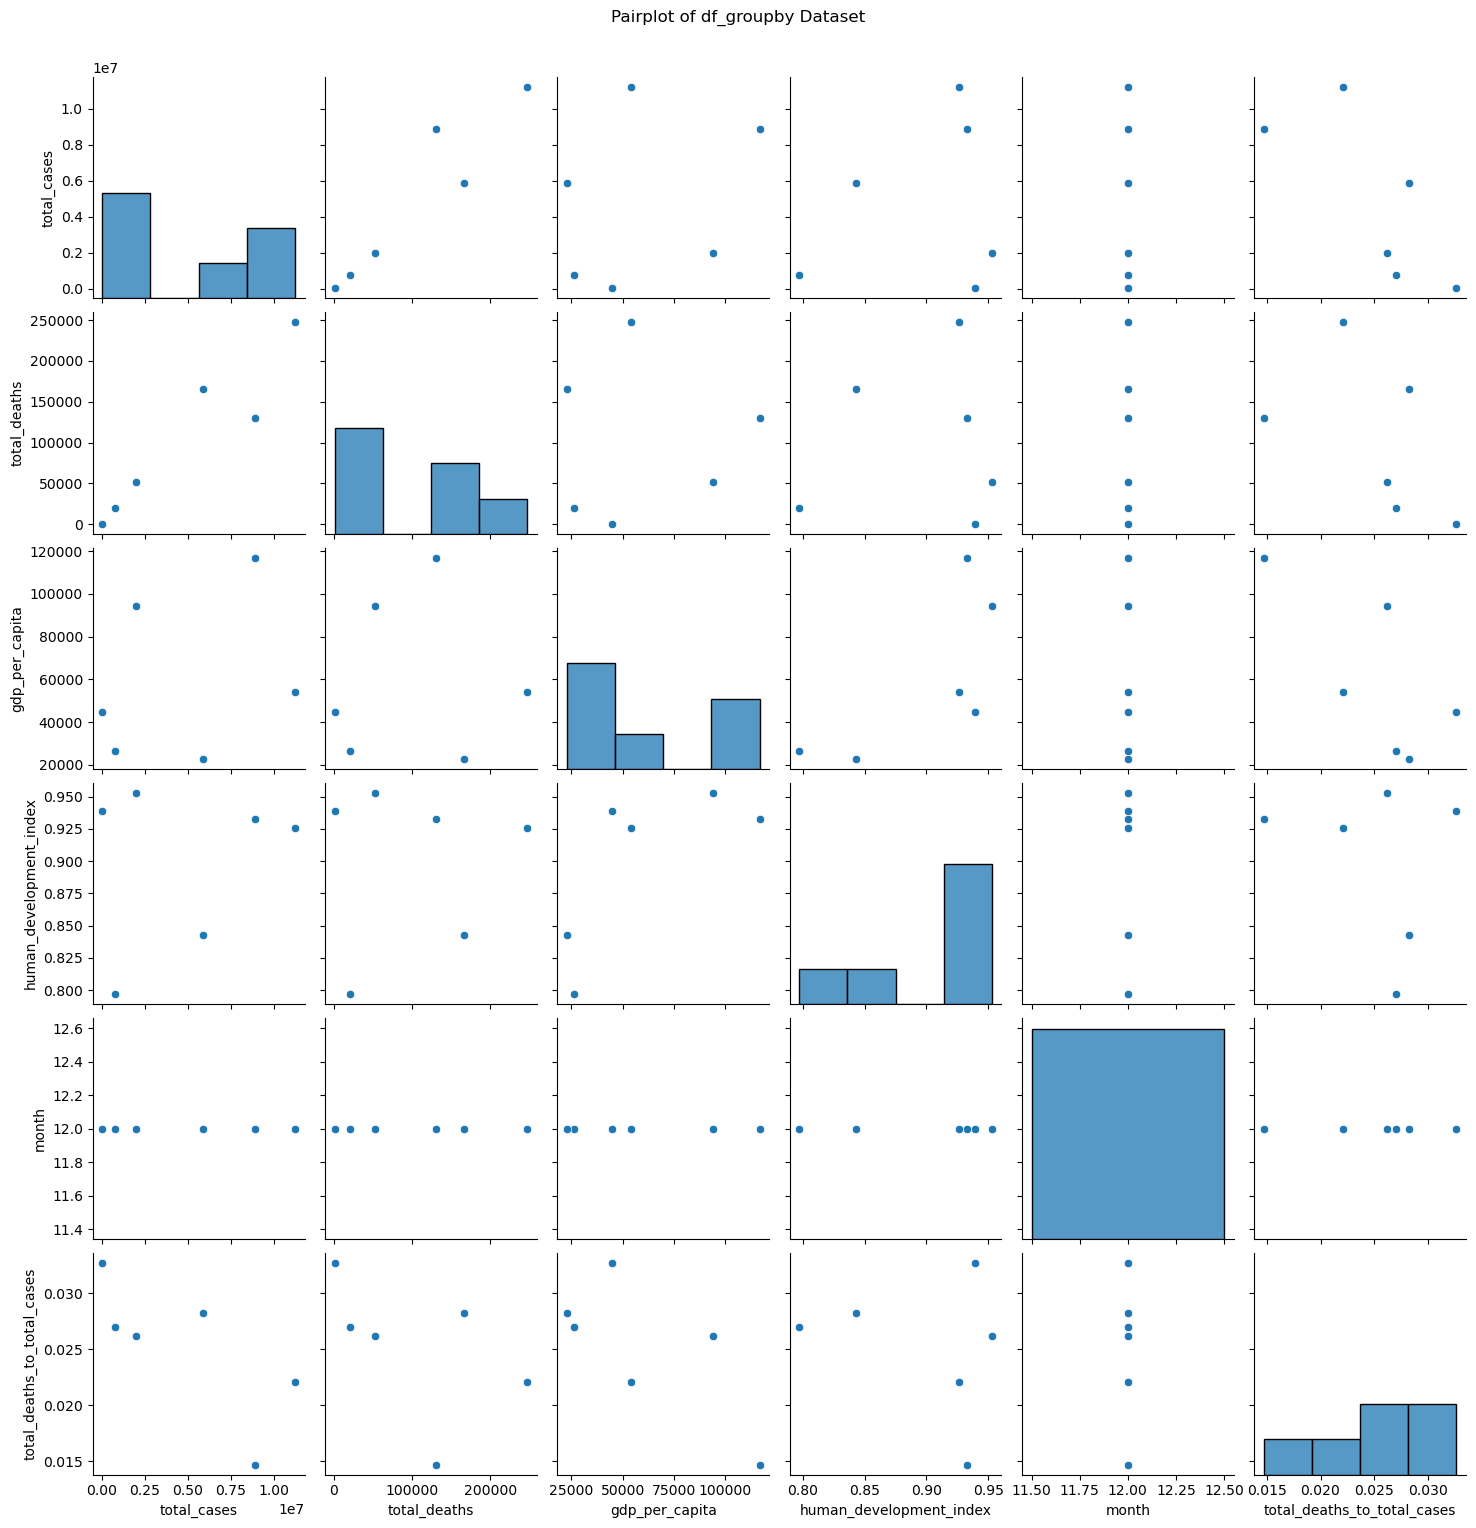

In [34]:
# c. Plot Pairplot on df_groupby dataset.
sns.pairplot(df_groupby)
plt.suptitle('Pairplot of df_groupby Dataset', y=1.02)
plt.show()


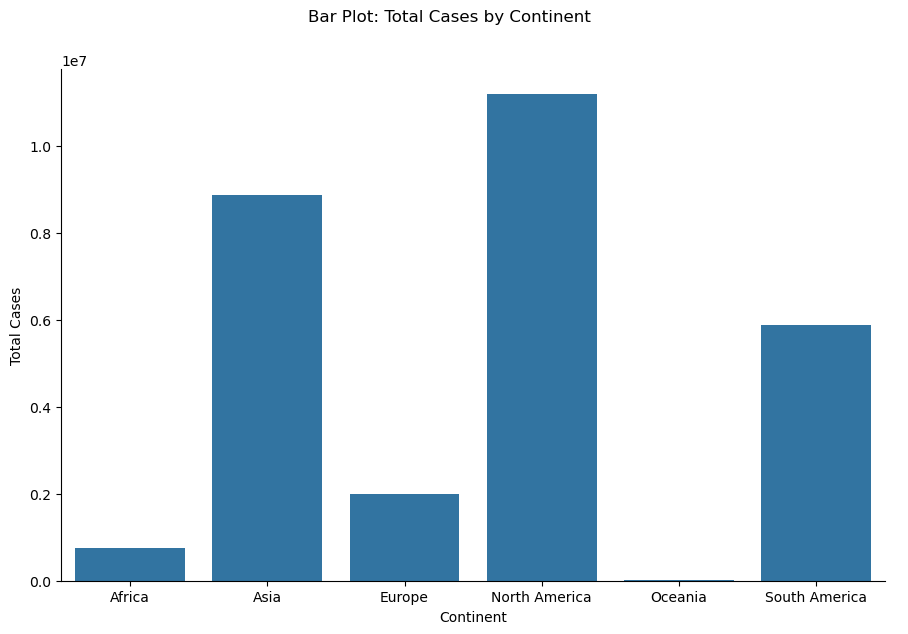

In [35]:
# d. Plot a bar plot of 'continent' column with 'total_cases' . Tip : using kind='bar' in seaborn catplot
g = sns.catplot(data=df_groupby, x='continent', y='total_cases', kind='bar', height=6, aspect=1.5)
g.fig.suptitle('Bar Plot: Total Cases by Continent', y=1.05)
plt.xlabel('Continent')
plt.ylabel('Total Cases')
plt.show()



In [36]:

# 10. Save the df_groupby dataframe in your local drive using pandas.to_csv function.
print("--- 10. Saving the Dataframe ---")
output_filename = 'df_groupby.csv'
df_groupby.to_csv(output_filename, index=False)
print(f"Dataframe 'df_groupby' successfully saved to '{output_filename}' in the local drive.")


--- 10. Saving the Dataframe ---
Dataframe 'df_groupby' successfully saved to 'df_groupby.csv' in the local drive.
